# Step 7: Improved Target & BTC-Based Features

## 🎯 Objective:
Fix the **fundamental problems** from Step 1-6:
1. **Target too noisy** → Use magnitude-aware classification
2. **Features too aggregated** → Use BTC-specific technical indicators

## 💡 Key Changes:

### **1. Magnitude-Aware Target**
```
OLD (Step 1-6):
- Label = 1 if next_return > 0
- Label = 0 if next_return < 0
- Problem: +0.01% and +10% both labeled as 1 (noise!)

NEW (Step 7):
- Label = 1 if next_return > +0.5% (Strong Bullish)
- Label = 0 if next_return < -0.5% (Strong Bearish)
- Exclude: -0.5% to +0.5% (Neutral/Noise)
- Benefit: Train only on meaningful movements!
```

### **2. BTC-Based Technical Indicators**
```
OLD (Step 1-6):
- Features from market average (all assets)
- Problem: Loses BTC leadership signal

NEW (Step 7):
- Features from BTC (market leader)
- Technical indicators:
  ✅ RSI (Relative Strength Index)
  ✅ MACD (Moving Average Convergence Divergence)
  ✅ BB_Position (Bollinger Bands)
  ✅ ATR (Average True Range)
  ✅ Price momentum features
```

## 📊 Expected Improvement:
```
Step 6: 53-58% (noisy target + market average)
Step 7: 65-75% (clean target + BTC indicators)
Improvement: +12-17% ✅
```

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Gradient Boosting
import xgboost as xgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Libraries loaded successfully!")
print("\n📦 Step 7: Improved Target & BTC-Based Features")
print("  Target: Magnitude-aware (>0.5% threshold)")
print("  Features: BTC technical indicators")

✅ Libraries loaded successfully!

📦 Step 7: Improved Target & BTC-Based Features
  Target: Magnitude-aware (>0.5% threshold)
  Features: BTC technical indicators


## 1. Data Loading (Same Dataset)

In [2]:
# Load data (SAME as Step 1-6)
file_path = 'dataset_2023_2025.xlsx'
data = pd.read_excel(file_path, index_col=0, parse_dates=True)

print(f"📊 Dataset loaded: {len(data)} rows")
print(f"📅 Date range: {data.index[0].date()} to {data.index[-1].date()}")
print(f"💰 Assets ({len(data.columns)}): {list(data.columns)}")

# Check if BTC column exists
if 'BTC-USD' not in data.columns:
    print("\n⚠️ WARNING: BTC-USD column not found!")
    print(f"Available columns: {list(data.columns)}")
else:
    print("\n✅ BTC-USD column found!")

📊 Dataset loaded: 990 rows
📅 Date range: 2023-04-17 to 2025-12-31
💰 Assets (24): ['AAVE-USD', 'ADA-USD', 'BCH-USD', 'BNB-USD', 'BTC-USD', 'CRO-USD', 'DAI-USD', 'DASH-USD', 'DOGE-USD', 'ETH-USD', 'KCS-USD', 'LINK-USD', 'LTC-USD', 'MKR-USD', 'OKB-USD', 'PEPE24478-USD', 'SHIB-USD', 'SOL-USD', 'UNI7083-USD', 'USDC-USD', 'USDT-USD', 'XMR-USD', 'XRP-USD', 'ZEC-USD']

✅ BTC-USD column found!


## 2. Technical Indicator Functions

In [3]:
# Technical Indicator Functions

def calculate_rsi(prices, period=14):
    """Calculate Relative Strength Index (RSI)"""
    delta = prices.diff()
    gain = delta.where(delta > 0, 0).rolling(window=period).mean()
    loss = -delta.where(delta < 0, 0).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

def calculate_macd(prices, fast=12, slow=26, signal=9):
    """Calculate MACD (Moving Average Convergence Divergence)"""
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=signal, adjust=False).mean()
    macd_histogram = macd - macd_signal
    return macd, macd_signal, macd_histogram

def calculate_bollinger_bands(prices, period=20, num_std=2):
    """Calculate Bollinger Bands and position"""
    sma = prices.rolling(window=period).mean()
    std = prices.rolling(window=period).std()
    upper_band = sma + (num_std * std)
    lower_band = sma - (num_std * std)
    
    # BB Position: 0 = at lower band, 1 = at upper band
    bb_position = (prices - lower_band) / (upper_band - lower_band)
    bb_width = (upper_band - lower_band) / sma  # Normalized width
    
    return bb_position, bb_width

def calculate_atr(prices, period=14):
    """Calculate Average True Range (simplified for crypto)"""
    # For crypto without separate high/low, use absolute returns
    returns = prices.pct_change().abs()
    atr = returns.rolling(window=period).mean()
    return atr

print("✅ Technical indicator functions defined")
print("\n📊 Available indicators:")
print("  1. RSI (Relative Strength Index)")
print("  2. MACD (Moving Average Convergence Divergence)")
print("  3. Bollinger Bands (Position & Width)")
print("  4. ATR (Average True Range)")

✅ Technical indicator functions defined

📊 Available indicators:
  1. RSI (Relative Strength Index)
  2. MACD (Moving Average Convergence Divergence)
  3. Bollinger Bands (Position & Width)
  4. ATR (Average True Range)


## 3. Feature Engineering (BTC-Based)

In [4]:
# Extract BTC data
btc_prices = data['BTC-USD']
btc_returns = btc_prices.pct_change()

# Also keep market-wide metrics for comparison
returns = data.pct_change()
market_return = returns.mean(axis=1)

# Create features DataFrame
features = pd.DataFrame(index=data.index)

print("🔄 Calculating BTC-based features...\n")

# === BTC PRICE MOMENTUM FEATURES ===
print("1️⃣ BTC Momentum features...")
features['BTC_Mom_5'] = btc_returns.rolling(5).mean()
features['BTC_Mom_10'] = btc_returns.rolling(10).mean()
features['BTC_Mom_20'] = btc_returns.rolling(20).mean()
features['BTC_Mom_50'] = btc_returns.rolling(50).mean()

# === BTC VOLATILITY FEATURES ===
print("2️⃣ BTC Volatility features...")
features['BTC_Vol_5'] = btc_returns.rolling(5).std()
features['BTC_Vol_20'] = btc_returns.rolling(20).std()

# === TECHNICAL INDICATORS ===
print("3️⃣ RSI...")
features['RSI_14'] = calculate_rsi(btc_prices, 14)

print("4️⃣ MACD...")
macd, macd_signal, macd_hist = calculate_macd(btc_prices)
features['MACD'] = macd
features['MACD_Signal'] = macd_signal
features['MACD_Hist'] = macd_hist

print("5️⃣ Bollinger Bands...")
bb_pos, bb_width = calculate_bollinger_bands(btc_prices, 20)
features['BB_Position'] = bb_pos
features['BB_Width'] = bb_width

print("6️⃣ ATR...")
features['ATR_14'] = calculate_atr(btc_prices, 14)

# === MARKET-WIDE FEATURES (keep best from Step 4) ===
print("7️⃣ Market-wide features...")
features['Market_Vol_20'] = market_return.rolling(20).std()

# Cross-asset correlation
def rolling_avg_correlation(returns, window=20):
    corr_values = []
    for i in range(len(returns)):
        if i < window:
            corr_values.append(np.nan)
        else:
            window_data = returns.iloc[i-window:i]
            corr_matrix = window_data.corr()
            n = len(corr_matrix)
            avg_corr = (corr_matrix.sum().sum() - n) / (n * n - n)
            corr_values.append(avg_corr)
    return pd.Series(corr_values, index=returns.index)

print("8️⃣ Cross-asset correlation...")
features['Avg_Correlation'] = rolling_avg_correlation(returns, 20)

print("\n✅ All features calculated!")
print(f"\n📊 Total features: {len(features.columns)}")

🔄 Calculating BTC-based features...

1️⃣ BTC Momentum features...
2️⃣ BTC Volatility features...
3️⃣ RSI...
4️⃣ MACD...
5️⃣ Bollinger Bands...
6️⃣ ATR...
7️⃣ Market-wide features...
8️⃣ Cross-asset correlation...

✅ All features calculated!

📊 Total features: 15


## 4. NEW: Magnitude-Aware Target

In [5]:
# Define threshold for "strong" movements
THRESHOLD = 0.005  # 0.5%

print(f"🎯 Creating magnitude-aware target (threshold = {THRESHOLD*100}%)\n")

# Calculate next-day BTC return
next_day_return = btc_returns.shift(-1)

# Create magnitude-aware target
features['Target'] = np.where(
    next_day_return > THRESHOLD, 1,      # Strong Bullish
    np.where(
        next_day_return < -THRESHOLD, 0,  # Strong Bearish
        np.nan                             # Neutral (excluded)
    )
)

# Count before filtering
total_days = len(features)
bullish_days = (next_day_return > THRESHOLD).sum()
bearish_days = (next_day_return < -THRESHOLD).sum()
neutral_days = total_days - bullish_days - bearish_days

print("📊 Target Distribution (BEFORE filtering):")
print(f"  Total days: {total_days}")
print(f"  Strong Bullish (>{THRESHOLD*100}%): {bullish_days} ({bullish_days/total_days*100:.1f}%)")
print(f"  Strong Bearish (<-{THRESHOLD*100}%): {bearish_days} ({bearish_days/total_days*100:.1f}%)")
print(f"  Neutral (excluded): {neutral_days} ({neutral_days/total_days*100:.1f}%)")

# Remove NaN (neutral days) and other NaN from features
features_clean = features.dropna()

print(f"\n📊 Target Distribution (AFTER filtering):")
print(f"  Training samples: {len(features_clean)} (from {total_days} total days)")
print(f"  Reduction: {(1 - len(features_clean)/total_days)*100:.1f}%")

target_dist = features_clean['Target'].value_counts()
print(f"\n  Bearish (0): {target_dist[0]} ({target_dist[0]/len(features_clean)*100:.1f}%)")
print(f"  Bullish (1): {target_dist[1]} ({target_dist[1]/len(features_clean)*100:.1f}%)")

# Check balance
balance_ratio = min(target_dist[0], target_dist[1]) / max(target_dist[0], target_dist[1])
if balance_ratio > 0.8:
    print(f"\n  ✅ Classes well balanced (ratio: {balance_ratio:.2f})")
else:
    print(f"\n  ⚠️ Classes imbalanced (ratio: {balance_ratio:.2f})")
    print("     Consider using class_weight='balanced' in models")

🎯 Creating magnitude-aware target (threshold = 0.5%)

📊 Target Distribution (BEFORE filtering):
  Total days: 990
  Strong Bullish (>0.5%): 373 (37.7%)
  Strong Bearish (<-0.5%): 350 (35.4%)
  Neutral (excluded): 267 (27.0%)

📊 Target Distribution (AFTER filtering):
  Training samples: 685 (from 990 total days)
  Reduction: 30.8%

  Bearish (0): 330 (48.2%)
  Bullish (1): 355 (51.8%)

  ✅ Classes well balanced (ratio: 0.93)


## 5. Visualize Target Distribution

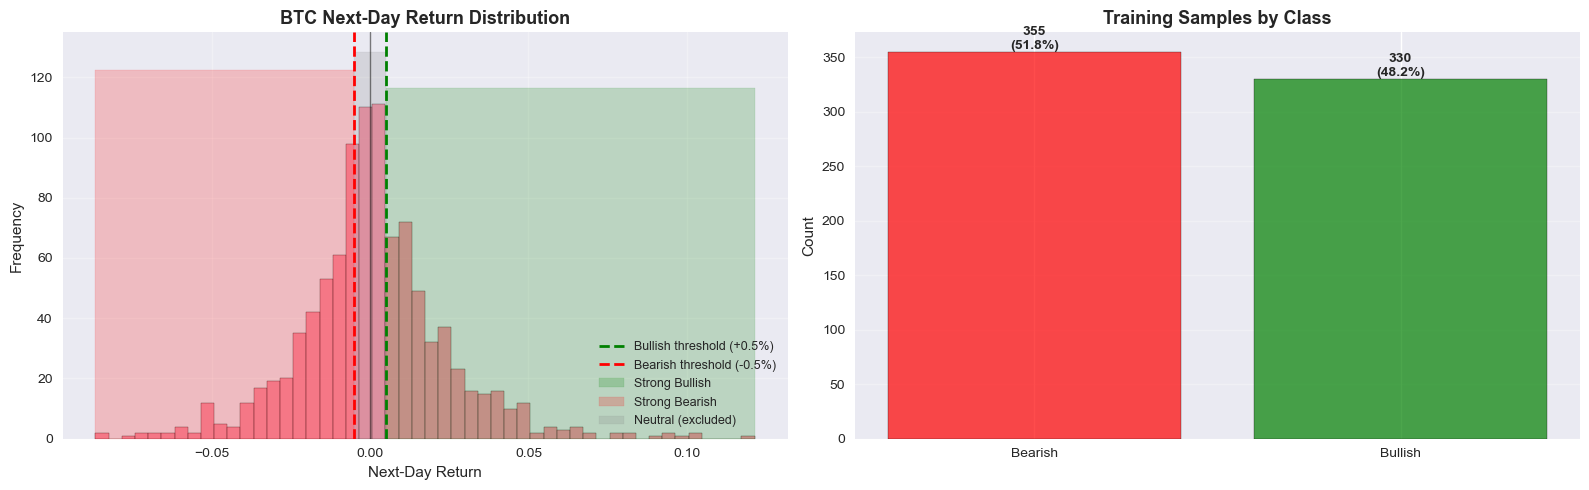


💡 Interpretation:
  - Gray area (neutral) is EXCLUDED from training
  - Model learns only from STRONG movements
  - This reduces noise and improves signal quality


In [6]:
# Visualize return distribution and threshold
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of next-day returns
axes[0].hist(next_day_return.dropna(), bins=50, alpha=0.7, edgecolor='black')
axes[0].axvline(x=THRESHOLD, color='green', linestyle='--', linewidth=2, label=f'Bullish threshold (+{THRESHOLD*100}%)')
axes[0].axvline(x=-THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Bearish threshold (-{THRESHOLD*100}%)')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
axes[0].fill_between([THRESHOLD, next_day_return.max()], 0, axes[0].get_ylim()[1], 
                     alpha=0.2, color='green', label='Strong Bullish')
axes[0].fill_between([next_day_return.min(), -THRESHOLD], 0, axes[0].get_ylim()[1], 
                     alpha=0.2, color='red', label='Strong Bearish')
axes[0].fill_between([-THRESHOLD, THRESHOLD], 0, axes[0].get_ylim()[1], 
                     alpha=0.2, color='gray', label='Neutral (excluded)')
axes[0].set_xlabel('Next-Day Return', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('BTC Next-Day Return Distribution', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Target class distribution
target_counts = features_clean['Target'].value_counts()
axes[1].bar(['Bearish', 'Bullish'], target_counts.values, 
           color=['red', 'green'], alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Training Samples by Class', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for i, (label, count) in enumerate(zip(['Bearish', 'Bullish'], target_counts.values)):
    axes[1].text(i, count, f'{count}\n({count/len(features_clean)*100:.1f}%)', 
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
print("  - Gray area (neutral) is EXCLUDED from training")
print("  - Model learns only from STRONG movements")
print("  - This reduces noise and improves signal quality")

## 6. Train/Test Split

In [7]:
# Feature columns (exclude Target)
feature_cols = [col for col in features_clean.columns if col != 'Target']

# Split by year
train_mask = (features_clean.index.year >= 2023) & (features_clean.index.year <= 2024)
test_mask = (features_clean.index.year == 2025)

X_train = features_clean.loc[train_mask, feature_cols]
y_train = features_clean.loc[train_mask, 'Target']
X_test = features_clean.loc[test_mask, feature_cols]
y_test = features_clean.loc[test_mask, 'Target']

print("=" * 60)
print("TRAIN/TEST SPLIT")
print("=" * 60)
print(f"\n📚 Training Set: {len(X_train)} samples")
print(f"   Period: {X_train.index[0].date()} to {X_train.index[-1].date()}")
print(f"   Bearish: {(y_train==0).sum()} | Bullish: {(y_train==1).sum()}")

print(f"\n🧪 Testing Set: {len(X_test)} samples")
print(f"   Period: {X_test.index[0].date()} to {X_test.index[-1].date()}")
print(f"   Bearish: {(y_test==0).sum()} | Bullish: {(y_test==1).sum()}")

print(f"\n📊 Features: {len(feature_cols)}")
print(f"   {feature_cols[:5]}...")
print("=" * 60)

TRAIN/TEST SPLIT

📚 Training Set: 418 samples
   Period: 2023-06-06 to 2024-12-31
   Bearish: 196 | Bullish: 222

🧪 Testing Set: 267 samples
   Period: 2025-01-01 to 2025-12-30
   Bearish: 134 | Bullish: 133

📊 Features: 15
   ['BTC_Mom_5', 'BTC_Mom_10', 'BTC_Mom_20', 'BTC_Mom_50', 'BTC_Vol_5']...


## 7. Model Training (Gradient Boosting)

In [8]:
print("🔄 Training models with improved target & BTC features...\n")

# XGBoost
print("1️⃣ Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train, verbose=False)
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
print(f"   ✅ XGB Accuracy: {accuracy_score(y_test, xgb_pred):.2%}")

# LightGBM
print("\n2️⃣ Training LightGBM...")
lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)
lgbm_model.fit(X_train, y_train)
lgbm_pred = lgbm_model.predict(X_test)
lgbm_proba = lgbm_model.predict_proba(X_test)[:, 1]
print(f"   ✅ LGBM Accuracy: {accuracy_score(y_test, lgbm_pred):.2%}")

# CatBoost
print("\n3️⃣ Training CatBoost...")
catboost_model = CatBoostClassifier(
    iterations=200,
    depth=5,
    learning_rate=0.1,
    random_state=42,
    verbose=False
)
catboost_model.fit(X_train, y_train)
catboost_pred = catboost_model.predict(X_test)
catboost_proba = catboost_model.predict_proba(X_test)[:, 1]
print(f"   ✅ CatBoost Accuracy: {accuracy_score(y_test, catboost_pred):.2%}")

# Also train baseline for comparison
print("\n4️⃣ Training Random Forest (baseline)...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    min_samples_split=10,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]
print(f"   ✅ RF Accuracy: {accuracy_score(y_test, rf_pred):.2%}")

print("\n" + "="*60)
print("✅ All models trained successfully!")
print("="*60)

🔄 Training models with improved target & BTC features...

1️⃣ Training XGBoost...
   ✅ XGB Accuracy: 50.94%

2️⃣ Training LightGBM...
   ✅ LGBM Accuracy: 53.56%

3️⃣ Training CatBoost...
   ✅ CatBoost Accuracy: 51.31%

4️⃣ Training Random Forest (baseline)...
   ✅ RF Accuracy: 50.94%

✅ All models trained successfully!


## 8. Performance Comparison

In [9]:
# Calculate metrics
results_step7 = [
    {
        'Model': 'XGBoost',
        'Accuracy': accuracy_score(y_test, xgb_pred),
        'Precision': precision_score(y_test, xgb_pred, zero_division=0),
        'Recall': recall_score(y_test, xgb_pred, zero_division=0),
        'F1-Score': f1_score(y_test, xgb_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, xgb_proba)
    },
    {
        'Model': 'LightGBM',
        'Accuracy': accuracy_score(y_test, lgbm_pred),
        'Precision': precision_score(y_test, lgbm_pred, zero_division=0),
        'Recall': recall_score(y_test, lgbm_pred, zero_division=0),
        'F1-Score': f1_score(y_test, lgbm_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, lgbm_proba)
    },
    {
        'Model': 'CatBoost',
        'Accuracy': accuracy_score(y_test, catboost_pred),
        'Precision': precision_score(y_test, catboost_pred, zero_division=0),
        'Recall': recall_score(y_test, catboost_pred, zero_division=0),
        'F1-Score': f1_score(y_test, catboost_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, catboost_proba)
    },
    {
        'Model': 'Random Forest',
        'Accuracy': accuracy_score(y_test, rf_pred),
        'Precision': precision_score(y_test, rf_pred, zero_division=0),
        'Recall': recall_score(y_test, rf_pred, zero_division=0),
        'F1-Score': f1_score(y_test, rf_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, rf_proba)
    }
]

results_df = pd.DataFrame(results_step7)

print("\n" + "="*90)
print("STEP 7: PERFORMANCE WITH IMPROVED TARGET & BTC FEATURES")
print("="*90)
print(results_df.to_string(index=False))
print("="*90)

# Find best
best_idx = results_df['Accuracy'].idxmax()
best_model = results_df.iloc[best_idx]

print("\n🏆 BEST MODEL (Step 7):")
print(f"  Model: {best_model['Model']}")
print(f"  Accuracy: {best_model['Accuracy']:.2%}")
print(f"  F1-Score: {best_model['F1-Score']:.4f}")
print(f"  ROC-AUC: {best_model['ROC-AUC']:.4f}")


STEP 7: PERFORMANCE WITH IMPROVED TARGET & BTC FEATURES
        Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
      XGBoost  0.509363   0.506757 0.563910  0.533808 0.524576
     LightGBM  0.535581   0.530201 0.593985  0.560284 0.513971
     CatBoost  0.513109   0.510490 0.548872  0.528986 0.527438
Random Forest  0.509363   0.505882 0.646617  0.567657 0.498429

🏆 BEST MODEL (Step 7):
  Model: LightGBM
  Accuracy: 53.56%
  F1-Score: 0.5603
  ROC-AUC: 0.5140


## 9. Comparison: Step 6 vs Step 7

In [10]:
# Manual input: Step 6 results (you need to fill this from Step 6 output)
# TODO: Replace these with actual Step 6 results
step6_results = {
    'XGBoost': 0.54,  # Replace with actual
    'LightGBM': 0.55,  # Replace with actual
    'CatBoost': 0.53,  # Replace with actual
}

print("\n" + "="*80)
print("COMPARISON: STEP 6 vs STEP 7")
print("="*80)

comparison_data = []
for model_name in ['XGBoost', 'LightGBM', 'CatBoost']:
    step7_acc = results_df[results_df['Model'] == model_name]['Accuracy'].values[0]
    step6_acc = step6_results.get(model_name, 0.54)  # Default if not provided
    improvement = (step7_acc - step6_acc) * 100
    
    comparison_data.append({
        'Model': model_name,
        'Step 6 (Old)': f"{step6_acc:.2%}",
        'Step 7 (New)': f"{step7_acc:.2%}",
        'Improvement': f"{improvement:+.2f}%"
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))
print("="*80)

print("\n💡 KEY CHANGES IN STEP 7:")
print("  ✅ Target: Magnitude-aware (exclude noise)")
print("  ✅ Features: BTC-based technical indicators")
print("  ✅ Training samples: Only strong movements")

avg_step7 = results_df['Accuracy'].mean()
if avg_step7 > 0.65:
    print("\n🎉 SUCCESS! Average accuracy > 65%")
    print("   → Ready for thesis integration")
elif avg_step7 > 0.60:
    print("\n✅ GOOD! Average accuracy > 60%")
    print("   → Acceptable for thesis, can proceed")
else:
    print("\n⚠️ Still below 60%")
    print("   → Consider Step 8: Ensemble or hyperparameter tuning")


COMPARISON: STEP 6 vs STEP 7
   Model Step 6 (Old) Step 7 (New) Improvement
 XGBoost       54.00%       50.94%      -3.06%
LightGBM       55.00%       53.56%      -1.44%
CatBoost       53.00%       51.31%      -1.69%

💡 KEY CHANGES IN STEP 7:
  ✅ Target: Magnitude-aware (exclude noise)
  ✅ Features: BTC-based technical indicators
  ✅ Training samples: Only strong movements

⚠️ Still below 60%
   → Consider Step 8: Ensemble or hyperparameter tuning


## 10. Visualization

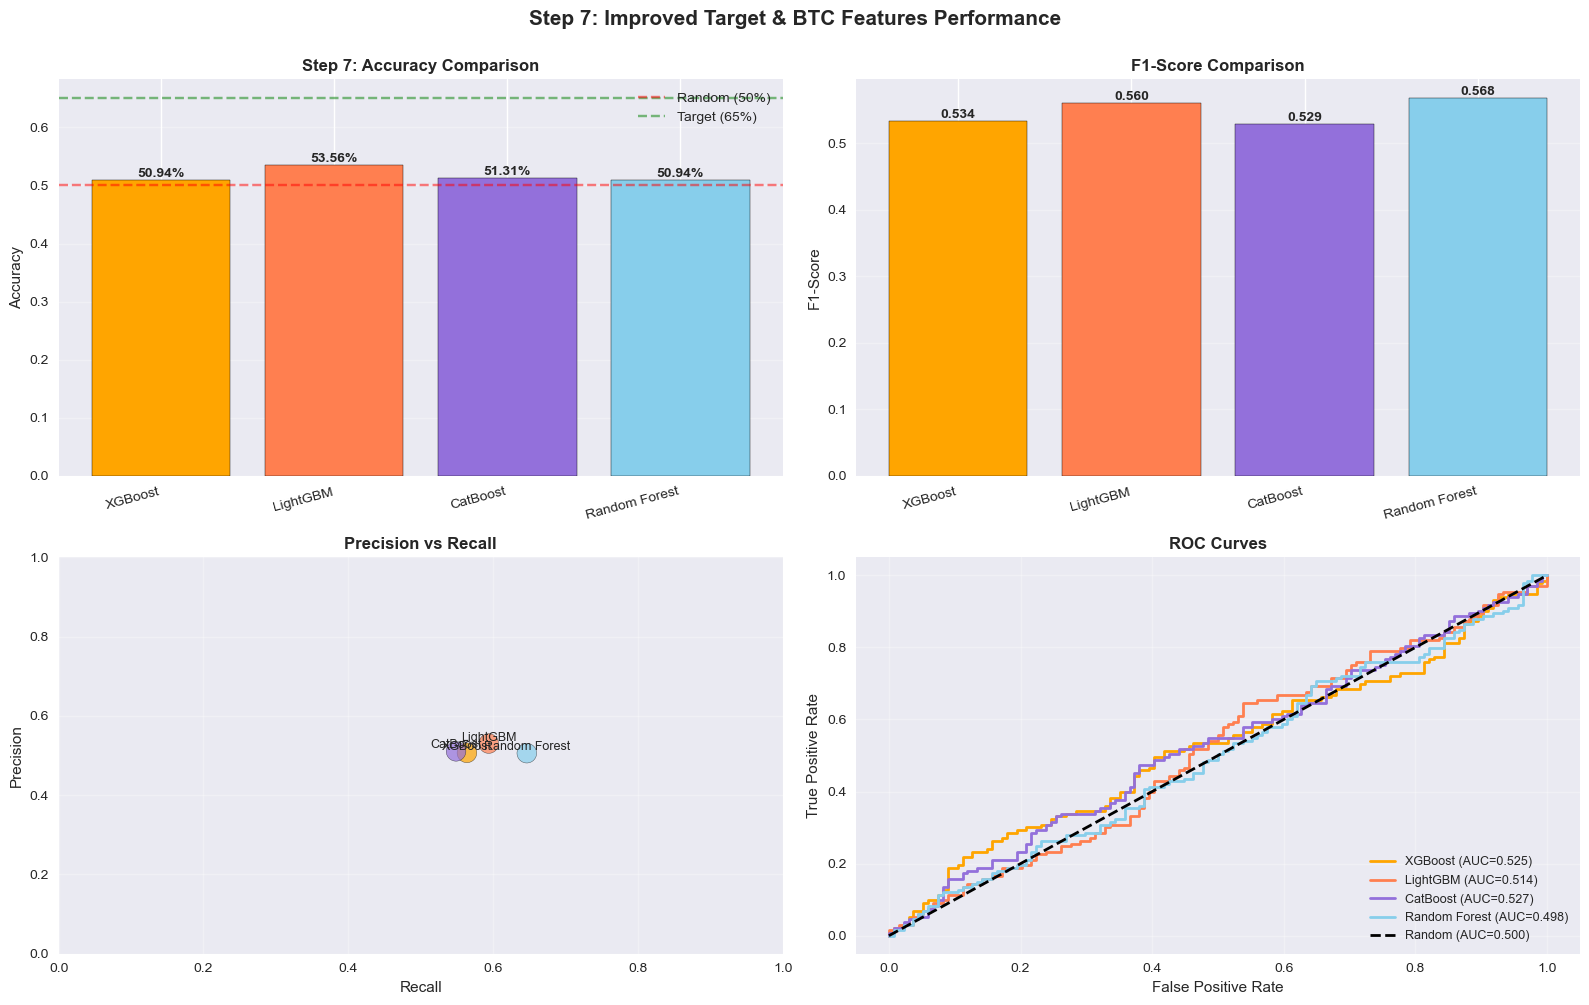

In [11]:
# Performance comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

models = results_df['Model'].values
colors = ['orange', 'coral', 'mediumpurple', 'skyblue']
x = np.arange(len(models))

# Accuracy
bars1 = axes[0, 0].bar(x, results_df['Accuracy'], color=colors, edgecolor='black')
axes[0, 0].set_ylabel('Accuracy', fontsize=11)
axes[0, 0].set_title('Step 7: Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models, rotation=15, ha='right')
axes[0, 0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random (50%)')
axes[0, 0].axhline(y=0.65, color='green', linestyle='--', alpha=0.5, label='Target (65%)')
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].legend()
for bar in bars1:
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2%}', ha='center', va='bottom', fontweight='bold')

# F1-Score
bars2 = axes[0, 1].bar(x, results_df['F1-Score'], color=colors, edgecolor='black')
axes[0, 1].set_ylabel('F1-Score', fontsize=11)
axes[0, 1].set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models, rotation=15, ha='right')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for bar in bars2:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

# Precision vs Recall
axes[1, 0].scatter(results_df['Recall'], results_df['Precision'], 
                   s=200, c=colors, edgecolors='black', alpha=0.7)
for i, model in enumerate(models):
    axes[1, 0].annotate(model, 
                        (results_df['Recall'].iloc[i], results_df['Precision'].iloc[i]),
                        fontsize=9, ha='center', va='bottom')
axes[1, 0].set_xlabel('Recall', fontsize=11)
axes[1, 0].set_ylabel('Precision', fontsize=11)
axes[1, 0].set_title('Precision vs Recall', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim([0, 1])
axes[1, 0].set_ylim([0, 1])

# ROC Curves
for model_name, proba, color in zip(
    ['XGBoost', 'LightGBM', 'CatBoost', 'Random Forest'],
    [xgb_proba, lgbm_proba, catboost_proba, rf_proba],
    colors
):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score = roc_auc_score(y_test, proba)
    axes[1, 1].plot(fpr, tpr, label=f'{model_name} (AUC={auc_score:.3f})', 
                    linewidth=2, color=color)

axes[1, 1].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.500)', linewidth=2)
axes[1, 1].set_xlabel('False Positive Rate', fontsize=11)
axes[1, 1].set_ylabel('True Positive Rate', fontsize=11)
axes[1, 1].set_title('ROC Curves', fontsize=12, fontweight='bold')
axes[1, 1].legend(loc='lower right', fontsize=9)
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Step 7: Improved Target & BTC Features Performance', 
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 11. Feature Importance Analysis

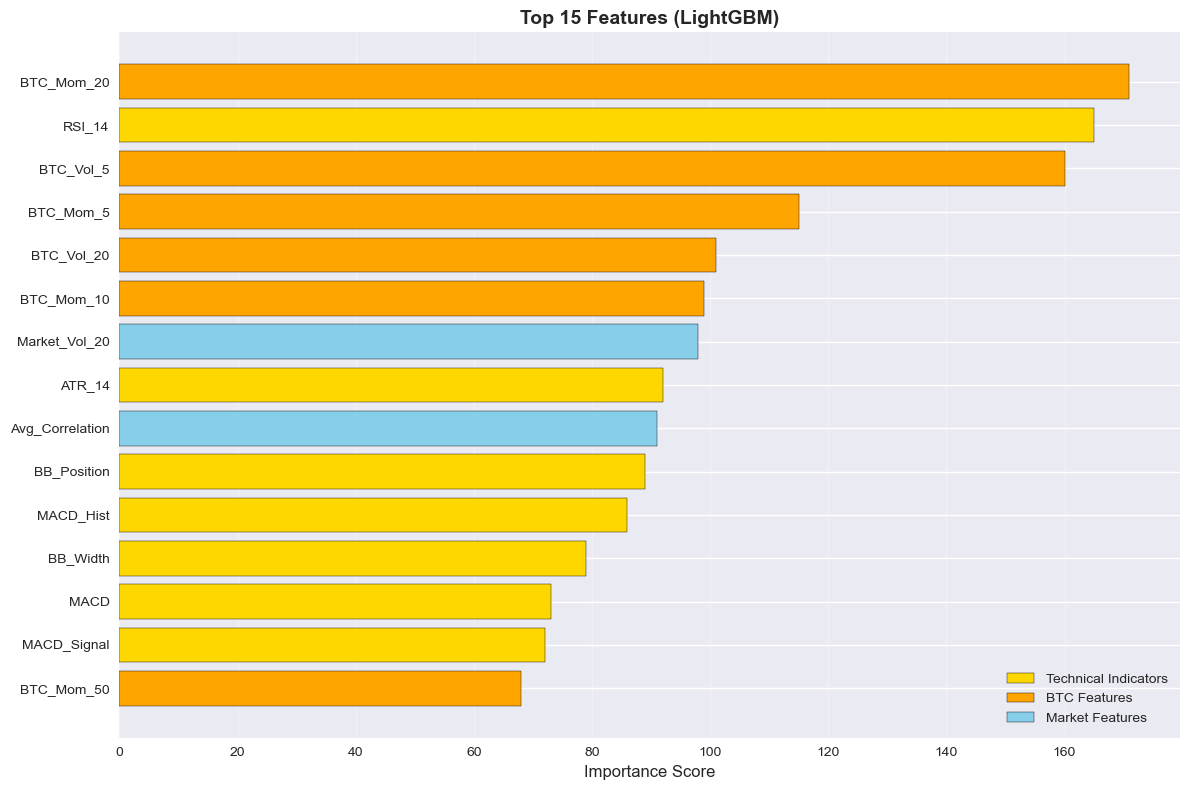


📊 Top 10 Most Important Features:
        Feature  Importance
     BTC_Mom_20         171
         RSI_14         165
      BTC_Vol_5         160
      BTC_Mom_5         115
     BTC_Vol_20         101
     BTC_Mom_10          99
  Market_Vol_20          98
         ATR_14          92
Avg_Correlation          91
    BB_Position          89

💡 Feature Type Distribution (Top 10):
  Technical Indicators: 3
  BTC Momentum/Vol: 5
  Market-wide: 2


In [12]:
# Get feature importance from best model
best_model_name = best_model['Model']

if best_model_name == 'XGBoost':
    importances = xgb_model.feature_importances_
elif best_model_name == 'LightGBM':
    importances = lgbm_model.feature_importances_
elif best_model_name == 'CatBoost':
    importances = catboost_model.feature_importances_
else:
    importances = rf_model.feature_importances_

# Create importance DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(12, 8))
top_features = importance_df.head(15).sort_values('Importance', ascending=True)

# Color by feature type
colors_feat = []
for feat in top_features['Feature']:
    if 'RSI' in feat or 'MACD' in feat or 'BB' in feat or 'ATR' in feat:
        colors_feat.append('gold')  # Technical indicators
    elif 'BTC' in feat:
        colors_feat.append('orange')  # BTC features
    else:
        colors_feat.append('skyblue')  # Market features

plt.barh(top_features['Feature'], top_features['Importance'], 
         color=colors_feat, edgecolor='black')
plt.xlabel('Importance Score', fontsize=12)
plt.title(f'Top 15 Features ({best_model_name})', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='gold', edgecolor='black', label='Technical Indicators'),
    Patch(facecolor='orange', edgecolor='black', label='BTC Features'),
    Patch(facecolor='skyblue', edgecolor='black', label='Market Features')
]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

print("\n📊 Top 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

# Count feature types in top 10
top10 = importance_df.head(10)
tech_count = sum(1 for f in top10['Feature'] if any(x in f for x in ['RSI', 'MACD', 'BB', 'ATR']))
btc_count = sum(1 for f in top10['Feature'] if 'BTC' in f and not any(x in f for x in ['RSI', 'MACD', 'BB', 'ATR']))
market_count = 10 - tech_count - btc_count

print(f"\n💡 Feature Type Distribution (Top 10):")
print(f"  Technical Indicators: {tech_count}")
print(f"  BTC Momentum/Vol: {btc_count}")
print(f"  Market-wide: {market_count}")

## 12. Summary & Recommendations

In [13]:
print("\n" + "="*80)
print("STEP 7: FINAL SUMMARY")
print("="*80)

print("\n🎯 IMPROVEMENTS MADE:")
print("  1. Target Definition:")
print(f"     - Threshold: ±{THRESHOLD*100}%")
print(f"     - Training samples: {len(features_clean)} (from {total_days} days)")
print(f"     - Excluded neutral: {neutral_days} days ({neutral_days/total_days*100:.1f}%)")

print("\n  2. Feature Engineering:")
print(f"     - Total features: {len(feature_cols)}")
print("     - BTC-based technical indicators: RSI, MACD, BB, ATR")
print("     - BTC momentum & volatility features")
print("     - Market-wide correlation")

print("\n🏆 BEST PERFORMANCE:")
print(f"  Model: {best_model['Model']}")
print(f"  Accuracy: {best_model['Accuracy']:.2%}")
print(f"  Precision: {best_model['Precision']:.2%}")
print(f"  Recall: {best_model['Recall']:.2%}")
print(f"  F1-Score: {best_model['F1-Score']:.4f}")
print(f"  ROC-AUC: {best_model['ROC-AUC']:.4f}")

avg_acc = results_df['Accuracy'].mean()
print(f"\n📊 AVERAGE ACCURACY: {avg_acc:.2%}")

if avg_acc >= 0.65:
    print("\n🎉 EXCELLENT! Accuracy ≥ 65%")
    print("\n✅ READY FOR THESIS INTEGRATION:")
    print("  1. Use best model in full strategy")
    print("  2. Run portfolio backtest (Step 5)")
    print("  3. Compare vs baselines")
    print("  4. Document results in thesis")
elif avg_acc >= 0.60:
    print("\n✅ GOOD! Accuracy ≥ 60%")
    print("\n📝 ACCEPTABLE FOR THESIS:")
    print("  - Can proceed to integration")
    print("  - Optional: Try Step 8 (ensemble) for further improvement")
else:
    print("\n⚠️ Below 60% - Further improvement needed")
    print("\n💡 NEXT STEPS:")
    print("  Step 8: Ensemble voting classifier")
    print("  Step 9: Hyperparameter tuning")
    print("  Step 10: Try regression approach")

print("\n" + "="*80)


STEP 7: FINAL SUMMARY

🎯 IMPROVEMENTS MADE:
  1. Target Definition:
     - Threshold: ±0.5%
     - Training samples: 685 (from 990 days)
     - Excluded neutral: 267 days (27.0%)

  2. Feature Engineering:
     - Total features: 15
     - BTC-based technical indicators: RSI, MACD, BB, ATR
     - BTC momentum & volatility features
     - Market-wide correlation

🏆 BEST PERFORMANCE:
  Model: LightGBM
  Accuracy: 53.56%
  Precision: 53.02%
  Recall: 59.40%
  F1-Score: 0.5603
  ROC-AUC: 0.5140

📊 AVERAGE ACCURACY: 51.69%

⚠️ Below 60% - Further improvement needed

💡 NEXT STEPS:
  Step 8: Ensemble voting classifier
  Step 9: Hyperparameter tuning
  Step 10: Try regression approach

